In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt

## Attribute Noise Results

In [2]:
# Load Attribute Noise Cleaned Dataset

an_cleaned = pd.read_csv('attribute_noise_cleaned.csv')
an_cleaned = an_cleaned.drop(['class_name', 'contents', 'max_noise'], axis=1)
X = an_cleaned.iloc[:, 0:1942]
y = an_cleaned.iloc[:, -1]

In [3]:
X

,Unnamed: 0,id,Unnamed: 2,.,a,if,return,throw,void,},...,{ },"| """,| |,"} """,} ',} :,} <,~ /,~ dp0node,class_value
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4989,4989,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4990,4990,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4991,4991,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4992,4992,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
y

0       1
1       1
2       1
3       1
4       1
       ..
4989    1
4990    1
4991    1
4992    1
4993    1
Name: noise, Length: 4994, dtype: int64

In [5]:
# Create training and test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)

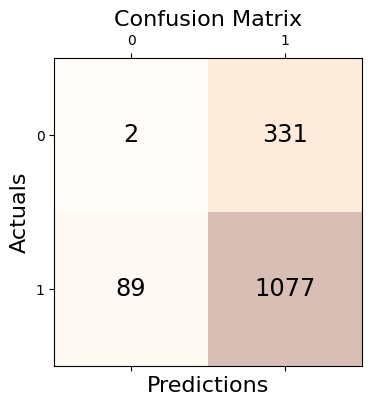

In [6]:
# Standardize the data set

sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

# Fit the SVC model

svc = SVC(kernel='linear', C=10.0, random_state=1)
svc.fit(X_train, y_train)

# Get the predictions

y_pred = svc.predict(X_test)

# Calculate the confusion matrix

conf_matrix = confusion_matrix(y_true=y_test, y_pred=y_pred)

# Print the confusion matrix using Matplotlib

fig, ax = plt.subplots(figsize=(4, 4))
ax.matshow(conf_matrix, cmap=plt.cm.Oranges, alpha=0.3)
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        ax.text(x=j, y=i,s=conf_matrix[i, j], va='center', ha='center', size='xx-large')

plt.xlabel('Predictions', fontsize=16)
plt.ylabel('Actuals', fontsize=16)
plt.title('Confusion Matrix', fontsize=16)
plt.show()

In [11]:
# Precision Score

print('Precision: %.2f' % (precision_score(y_test, y_pred) * 100))

Precision: 76.49


In [12]:
# Recall Score

print('Recall: %.2f' % (recall_score(y_test, y_pred) * 100))

Recall: 92.37


In [13]:
# F1 Score

print('F1 Score: %.2f' % (f1_score(y_test, y_pred) * 100))

F1 Score: 83.68


In [14]:
# Accuracy Score

print('Accuracy: %.2f' % (accuracy_score(y_test, y_pred) * 100))

Accuracy: 71.98
